### 0.Computer vision libs in pytorch:
torchvision.datasets->datasets
torchvision.models->transfer learning
torchvision.transforms->functions for manipulating your vision data
torch.utils.datya.Datset->Base dataset class for pytorch
torch.utils.data.DataLoaded->Creates python iterable over a dataset

In [16]:
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
torch.__version__,torchvision.__version__

('2.11.0+cpu', '0.26.0+cpu')

### 1.Getting a dataset:
The dataset we will be using is fashionmnist from torchvision.datasets:

In [17]:
#Setup training data:
from torchvision import datasets
train_data=datasets.FashionMNIST(root='data'#Where to download data to
                                 ,train=True #We want training version of dataset
                                 ,download=True,
                                 transform=torchvision.transforms.ToTensor() #Convert images to tensor ,
                                 ,target_transform=None #Dont transform labels
                                 )
#Setup testing data:
test_data=datasets.FashionMNIST(root='data',
                                train=False,
                                download=True,
                                transform=torchvision.transforms.ToTensor(),
                                target_transform=None)

In [18]:
len(train_data),len(test_data)

(60000, 10000)

In [23]:
#See the first training example:
image,label=train_data[0]
image

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [24]:
class_names=train_data.classes #.classes is builtin for torchvision datasets
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [25]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

### 1.1 Check input and output shapes of data:

In [28]:
#Check the shape of our image:
print(f"Image shape:{image.shape},label shape:{label}")
#1->color channel
#28->height
#28->width

Image shape:torch.Size([1, 28, 28]),label shape:9


For deep learning image representaion we have either:
NCHW:batchsize-color_channels-height-width
or NHCW:batch_size-height-width,color_channels

### 1.2 Visualizng our data:

Image shape:torch.Size([1, 28, 28])


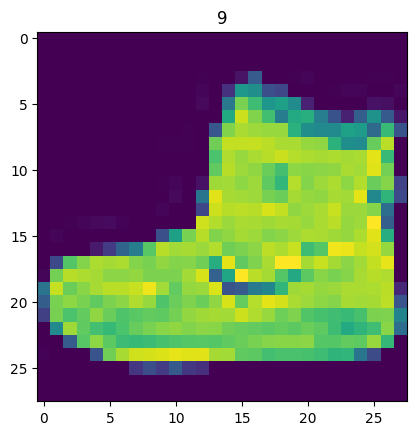

In [32]:
image,label=train_data[0]
print(f"Image shape:{image.shape}")
#matplotlpib expects color_channels last since we have them first we will squeeze to get rid of it
plt.imshow(image.squeeze())
plt.title(label)
plt.show()

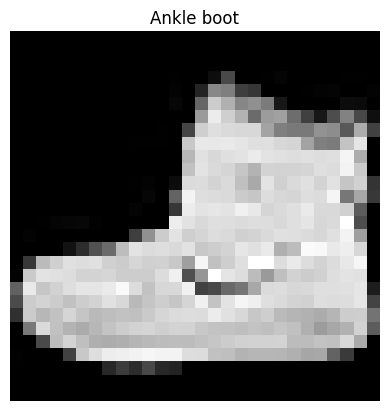

In [36]:
plt.imshow(image.squeeze(),cmap='gray')
plt.title(class_names[label])
plt.axis(False)
plt.show()

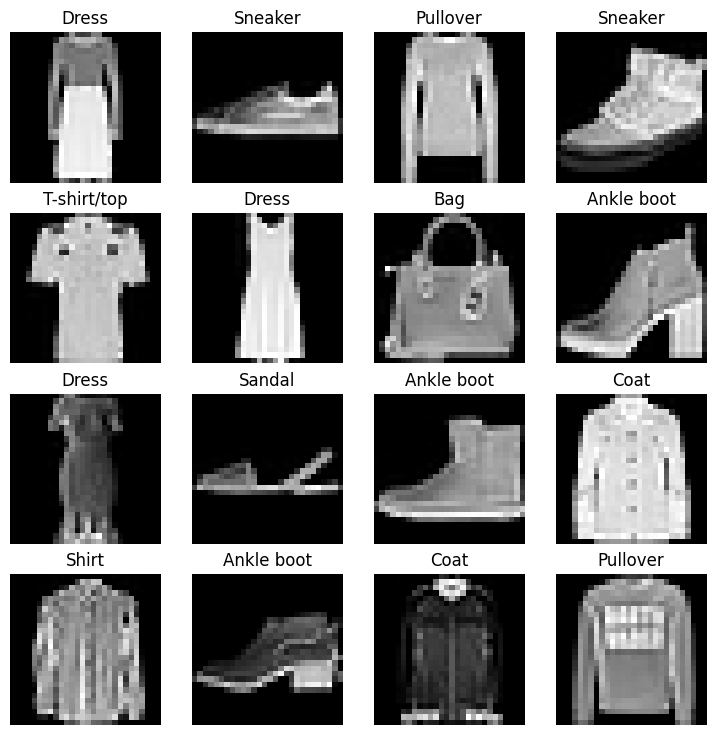

In [49]:
#Plot more images:
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  #size=[1]->get tensor with one value and dim
  #.item->makes the single values into an int
  img,label=train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze(),cmap='grey')
  plt.axis(False)
  plt.title(class_names[label])
